In [1]:
import torch
import torch.nn as nn
import numpy as np
import joblib
import os
import sys
import matplotlib.pyplot as plt

In [2]:
common_dir_name = 'commons' 
common_dir_path = os.path.join(os.path.dirname(os.getcwd()), common_dir_name)
if common_dir_path not in sys.path:
    sys.path.append(common_dir_path)

In [3]:
from utils_chkpt import load_checkpoint
from nn_model_plausible import PlausibleHNN
from utils_orbit import scipy_predict_qp_model_orbits
from utils_orbit import ground_truth_orbits
from utils_energy import calculate_gt_hamiltonian
from utils_energy import calculate_nn_hamiltonian
from utils_plot import get_global_limits
from utils_plot import eval_on_test_set

In [4]:
torch.set_default_dtype(torch.float64)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device='cpu'

In [5]:
import gc
gc.collect()

0

In [6]:
EPOC  = 6
EPOCS = 20

LAYERS = 3
FAC = 2

MODEL_NAME=f"p-hnn({LAYERS})({FAC})"
MODEL_DIR="./checkpoints/multi-scale-v2"

BATCH_SZ = 1024
LR_INIT = 1e-4
MIN_LR = 1e-6
PATIENCE = 3

PLOT_ROOT_DIR="./figures"

EVAL_PLOT_DIR=f"{PLOT_ROOT_DIR}/eval"
EVAL_FIG_DIR=f"{EVAL_PLOT_DIR}/multi-scale-v2"
if not os.path.exists(EVAL_FIG_DIR):
    os.makedirs(EVAL_FIG_DIR, exist_ok=True)

FIT_PLOT_DIR=f"{PLOT_ROOT_DIR}/fit"
FIT_FIG_DIR=f"{FIT_PLOT_DIR}/multi-scale-v2"
if not os.path.exists(FIT_FIG_DIR):
    os.makedirs(FIT_FIG_DIR, exist_ok=True)

PREFIX="scipy_"
POSTFIX=f"_bs_{BATCH_SZ}_lr_{LR_INIT:.0e}_pat_{PATIENCE}"


In [7]:
extend_time_window_upto_200Y = False # True
extend_time_window_upto_100Y = True

if extend_time_window_upto_200Y:
    extend_time_window_upto_100Y = True

IMG_SAVE = False

In [8]:
stats = joblib.load(f'{MODEL_DIR}/ds_mlt_scalev.pkl')
q_max = stats['q_max']
p_max = stats['p_max']
dq_max = stats['dq_max']
dp_max = stats['dp_max']
print('Loaded q_max:', q_max)
print('Loaded p_max:', p_max)
print('Loaded dq_max:', dq_max)
print('Loaded dp_max:', dp_max)

Loaded q_max: [9.76072648e-03 9.76072648e-03 9.76072648e-03 4.75583884e-01
 4.75583884e-01 4.75583884e-01 7.36863945e-01 7.36863945e-01
 7.36863945e-01 1.02686268e+00 1.02686268e+00 1.02686268e+00
 1.67630733e+00 1.67630733e+00 1.67630733e+00 5.46068795e+00
 5.46068795e+00 5.46068795e+00 1.00744475e+01 1.00744475e+01
 1.00744475e+01 2.01200978e+01 2.01200978e+01 2.01200978e+01
 3.03526597e+01 3.03526597e+01 3.03526597e+01 4.93888156e+01
 4.93888156e+01 4.93888156e+01]
Loaded p_max: [3.46495531e-03 3.46495531e-03 3.46495531e-03 2.06714022e-06
 2.06714022e-06 2.06714022e-06 1.82197738e-05 1.82197738e-05
 1.82197738e-05 1.92061355e-05 1.92061355e-05 1.92061355e-05
 1.80700775e-06 1.80700775e-06 1.80700775e-06 2.76473141e-03
 2.76473141e-03 2.76473141e-03 6.14944300e-04 6.14944300e-04
 6.14944300e-04 6.57900454e-05 6.57900454e-05 6.57900454e-05
 5.96100788e-05 5.96100788e-05 5.96100788e-05 8.45747270e-09
 8.45747270e-09 8.45747270e-09]
Loaded dq_max: [3.46495531e-03 3.46495531e-03 3.464955

In [9]:
weight_filename = f"{MODEL_NAME}_ep_{EPOC}_of_{EPOCS}{POSTFIX}"
weight_filepath = f"{MODEL_DIR}/" + weight_filename + '.pth'

print('weight_file_path":', weight_filepath)

model = PlausibleHNN(fac=FAC, num_layers=LAYERS)
model.double()
model.to(device)

load_checkpoint(model, optimizer=None, file_path=weight_filepath) 

weight_file_path": ./checkpoints/multi-scale-v2/p-hnn(3)(2)_ep_6_of_20_bs_1024_lr_1e-04_pat_3.pth
🚀 Loaded checkpoint from './checkpoints/multi-scale-v2/p-hnn(3)(2)_ep_6_of_20_bs_1024_lr_1e-04_pat_3.pth' (Epoch 6)


(6, 0.0008752127687885377)

In [10]:
print(model)
print(f"Number of parameters: {sum(p.numel() for p in model.parameters())}")

PlausibleHNN(
  (v_mlp): MLP(
    (net): Sequential(
      (0): Linear(in_features=30, out_features=270, bias=True)
      (1): EvenActivation()
      (2): Linear(in_features=270, out_features=270, bias=True)
      (3): EvenActivation()
      (4): Linear(in_features=270, out_features=1, bias=False)
    )
  )
)
Number of parameters: 81840


In [11]:
print(f'T-net attention weights: {model.w}')

T-net attention weights: Parameter containing:
tensor([0.5001, 0.5001, 0.5001, 0.5001, 0.5001, 0.5001, 0.5001, 0.5001, 0.5001,
        0.5001, 0.5001, 0.5103, 0.5001, 0.5001, 0.5001, 0.5001, 0.5001, 0.5001,
        0.5001, 0.5001, 0.5001, 0.5001, 0.5001, 0.5001, 0.5001, 0.5001, 0.5001,
        0.5001, 0.5001, 0.5001], device='cuda:0', requires_grad=True)


In [12]:
target_path = os.path.join(os.path.dirname(os.getcwd()), 'data_ode')

if target_path not in sys.path:
    sys.path.append(target_path)
pos_path = f"{target_path}/q.npz"
mom_path = f"{target_path}/p.npz"
dpos_path = f"{target_path}/dq.npz"
dmom_path = f"{target_path}/dp.npz"

plt_pars = get_global_limits(pos_path)

In [13]:
q_path = f"{target_path}/q.npz"
p_path = f"{target_path}/p.npz"

i: 0, interval=[0 : 1000]
x0: (1, 60)


/home/danieljh/py-venv/lib/python3.12/site-packages/torch/autograd/graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


scipy_eval_[0 : 1000]_p-hnn(3)(2)_ep_6_of_20_bs_1024_lr_1e-04_pat_3.webp


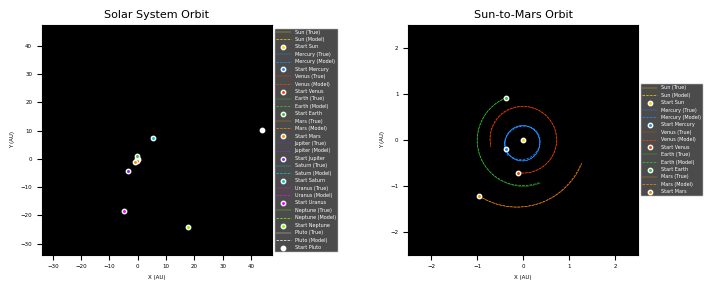

scipy_metric_[0 : 1000]_p-hnn(3)(2)_ep_6_of_20_bs_1024_lr_1e-04_pat_3.webp


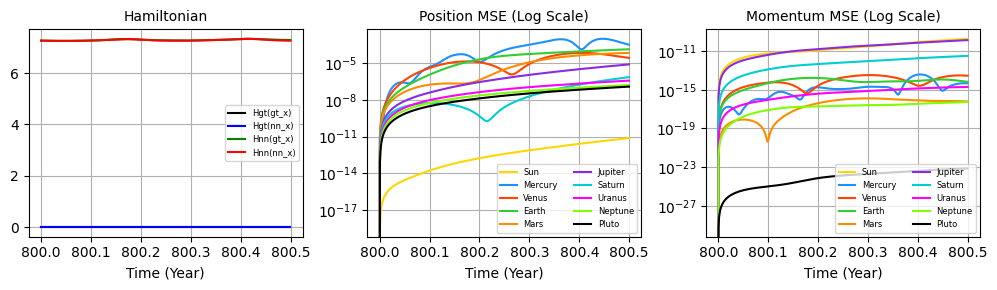

i: 1, interval=[0 : 2000]
x0: (1, 60)
scipy_eval_[0 : 2000]_p-hnn(3)(2)_ep_6_of_20_bs_1024_lr_1e-04_pat_3.webp


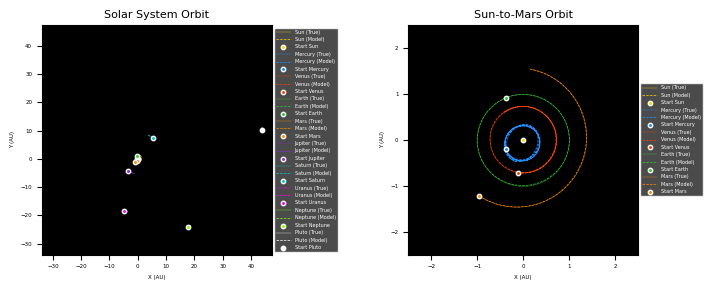

scipy_metric_[0 : 2000]_p-hnn(3)(2)_ep_6_of_20_bs_1024_lr_1e-04_pat_3.webp


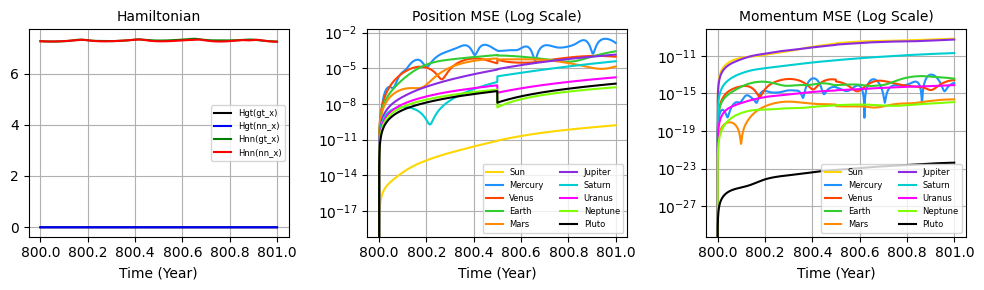

i: 2, interval=[0 : 4000]
x0: (1, 60)
scipy_eval_[0 : 4000]_p-hnn(3)(2)_ep_6_of_20_bs_1024_lr_1e-04_pat_3.webp


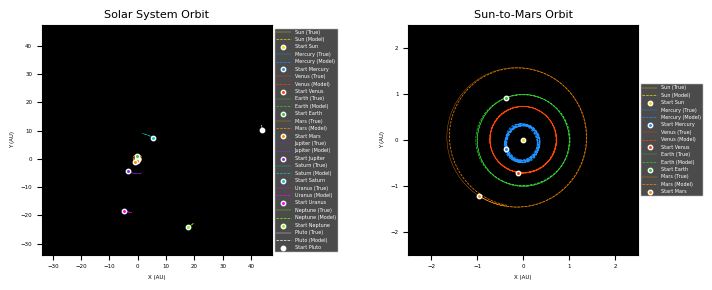

scipy_metric_[0 : 4000]_p-hnn(3)(2)_ep_6_of_20_bs_1024_lr_1e-04_pat_3.webp


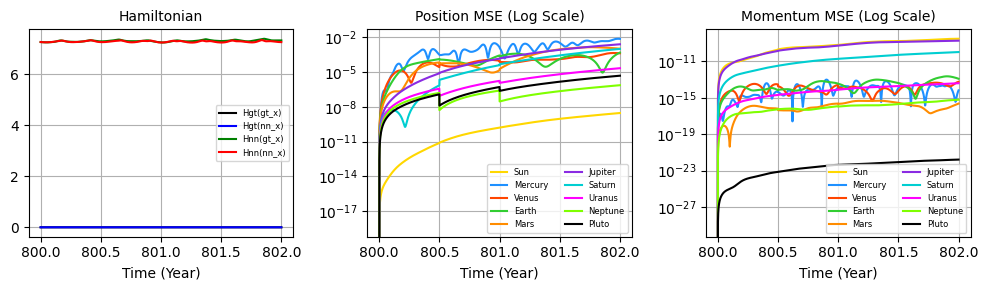

i: 3, interval=[0 : 6000]
x0: (1, 60)
scipy_eval_[0 : 6000]_p-hnn(3)(2)_ep_6_of_20_bs_1024_lr_1e-04_pat_3.webp


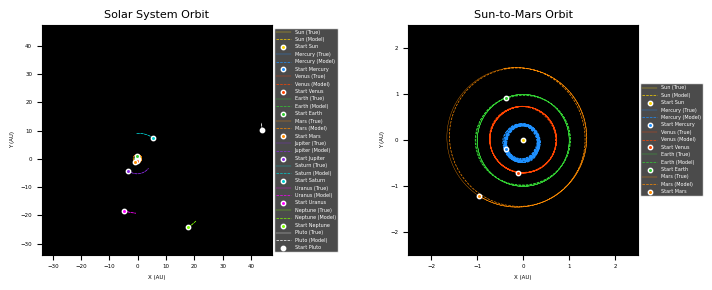

scipy_metric_[0 : 6000]_p-hnn(3)(2)_ep_6_of_20_bs_1024_lr_1e-04_pat_3.webp


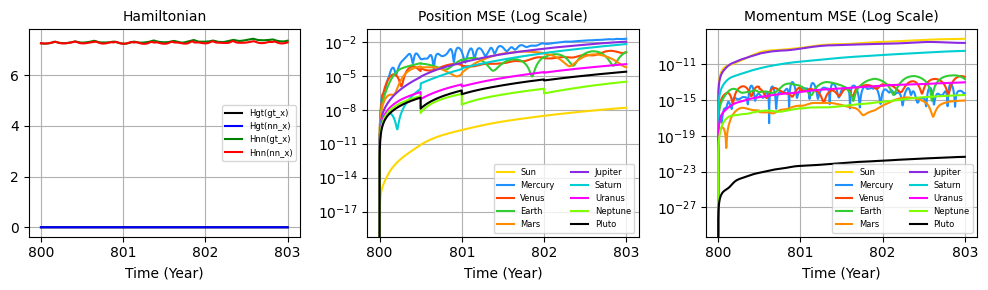

i: 4, interval=[0 : 8000]
x0: (1, 60)
scipy_eval_[0 : 8000]_p-hnn(3)(2)_ep_6_of_20_bs_1024_lr_1e-04_pat_3.webp


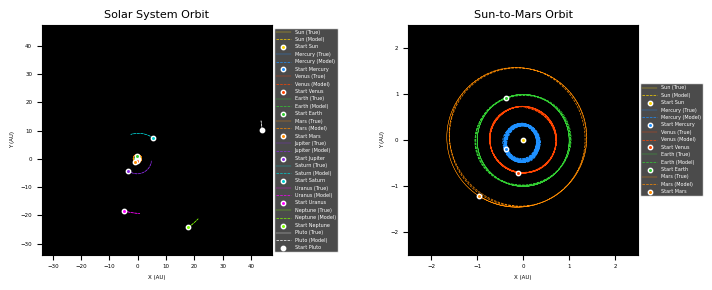

scipy_metric_[0 : 8000]_p-hnn(3)(2)_ep_6_of_20_bs_1024_lr_1e-04_pat_3.webp


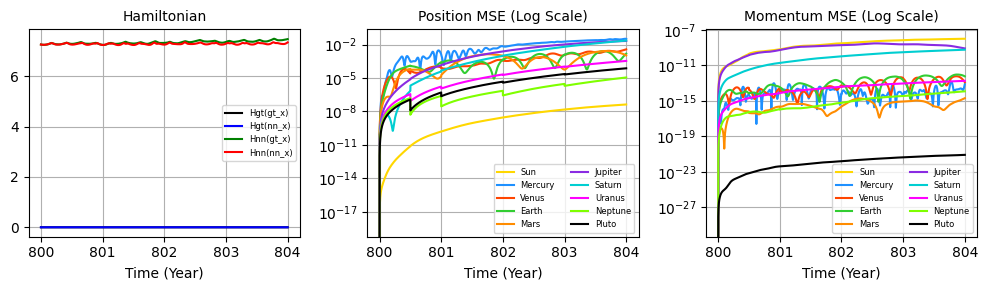

i: 5, interval=[0 : 10000]
x0: (1, 60)
scipy_eval_[0 : 10000]_p-hnn(3)(2)_ep_6_of_20_bs_1024_lr_1e-04_pat_3.webp


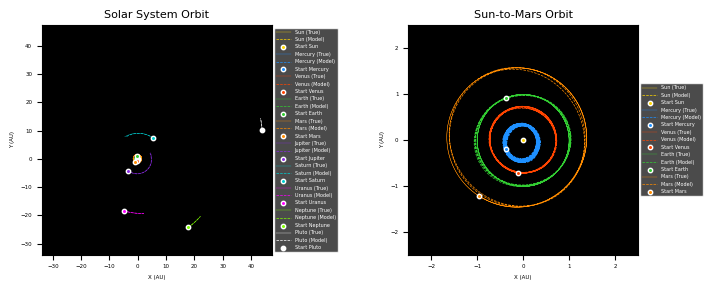

scipy_metric_[0 : 10000]_p-hnn(3)(2)_ep_6_of_20_bs_1024_lr_1e-04_pat_3.webp


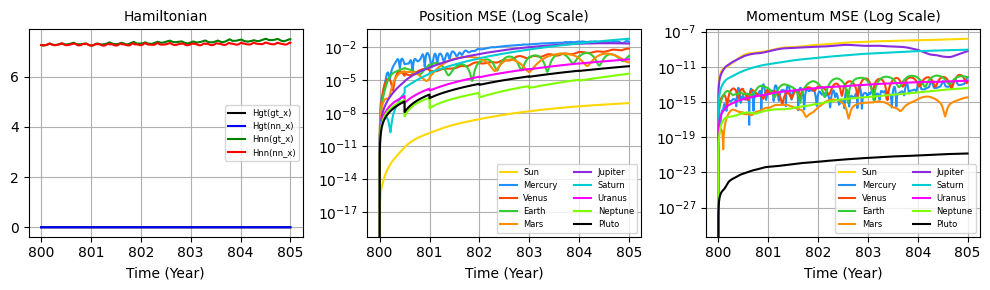

i: 6, interval=[0 : 20000]
x0: (1, 60)
scipy_eval_[0 : 20000]_p-hnn(3)(2)_ep_6_of_20_bs_1024_lr_1e-04_pat_3.webp


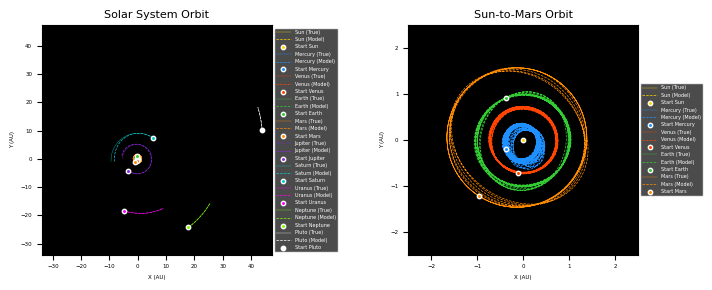

scipy_metric_[0 : 20000]_p-hnn(3)(2)_ep_6_of_20_bs_1024_lr_1e-04_pat_3.webp


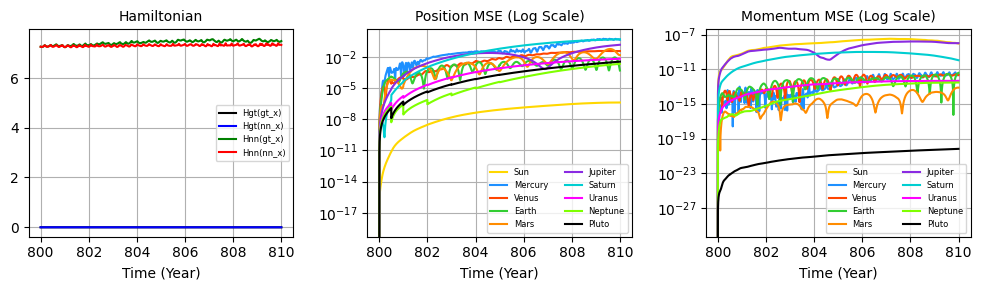

i: 7, interval=[0 : 30000]
x0: (1, 60)
scipy_eval_[0 : 30000]_p-hnn(3)(2)_ep_6_of_20_bs_1024_lr_1e-04_pat_3.webp


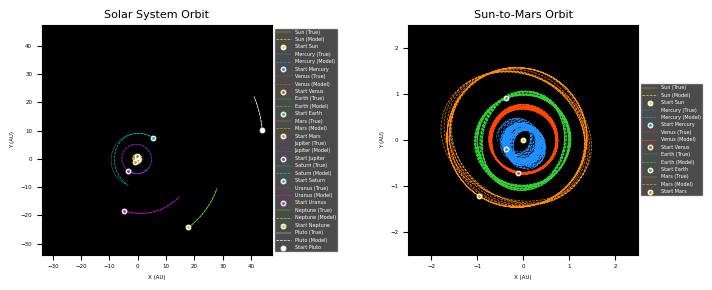

scipy_metric_[0 : 30000]_p-hnn(3)(2)_ep_6_of_20_bs_1024_lr_1e-04_pat_3.webp


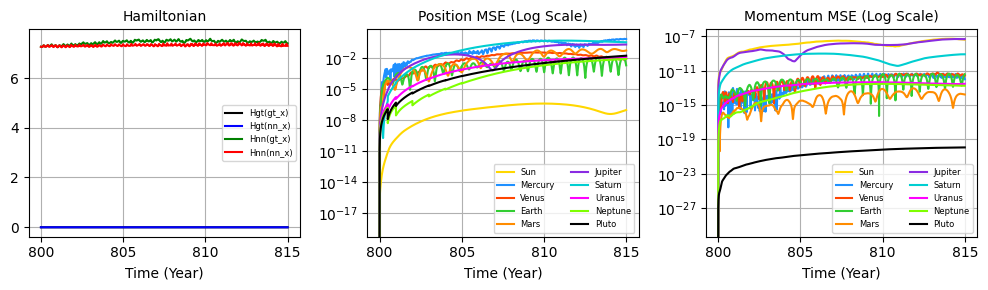

i: 8, interval=[0 : 40000]
x0: (1, 60)
scipy_eval_[0 : 40000]_p-hnn(3)(2)_ep_6_of_20_bs_1024_lr_1e-04_pat_3.webp


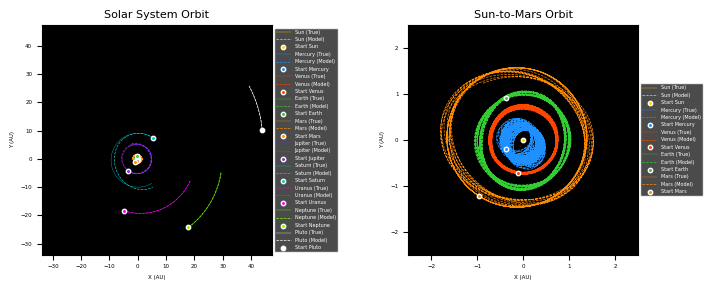

scipy_metric_[0 : 40000]_p-hnn(3)(2)_ep_6_of_20_bs_1024_lr_1e-04_pat_3.webp


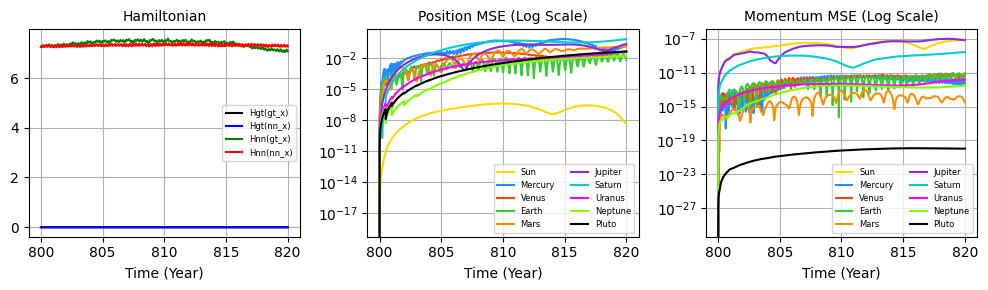

i: 9, interval=[0 : 100000]
x0: (1, 60)
scipy_eval_[0 : 100000]_p-hnn(3)(2)_ep_6_of_20_bs_1024_lr_1e-04_pat_3.webp


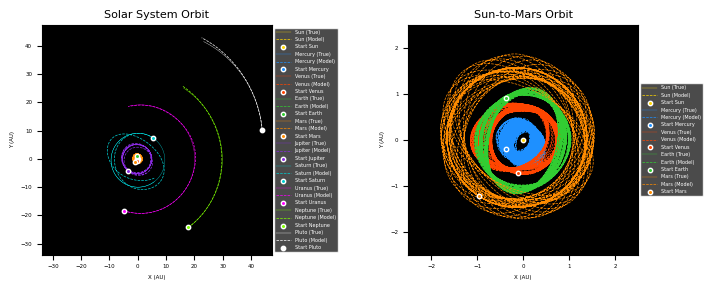

scipy_metric_[0 : 100000]_p-hnn(3)(2)_ep_6_of_20_bs_1024_lr_1e-04_pat_3.webp


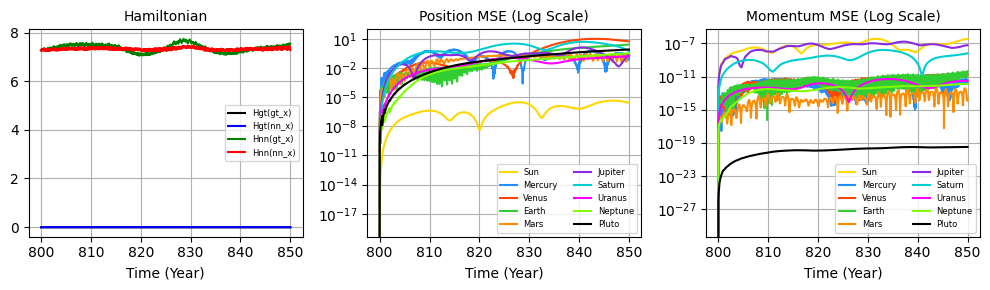

i: 10, interval=[0 : 200000]
x0: (1, 60)
scipy_eval_[0 : 200000]_p-hnn(3)(2)_ep_6_of_20_bs_1024_lr_1e-04_pat_3.webp


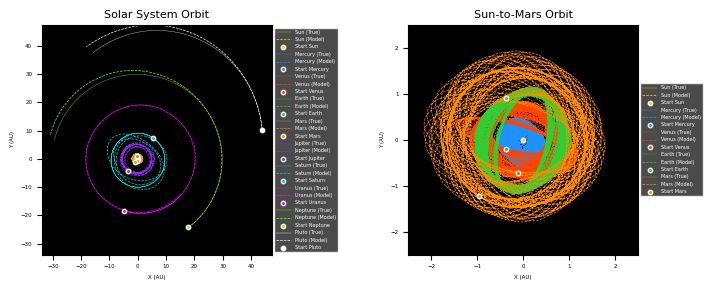

scipy_metric_[0 : 200000]_p-hnn(3)(2)_ep_6_of_20_bs_1024_lr_1e-04_pat_3.webp


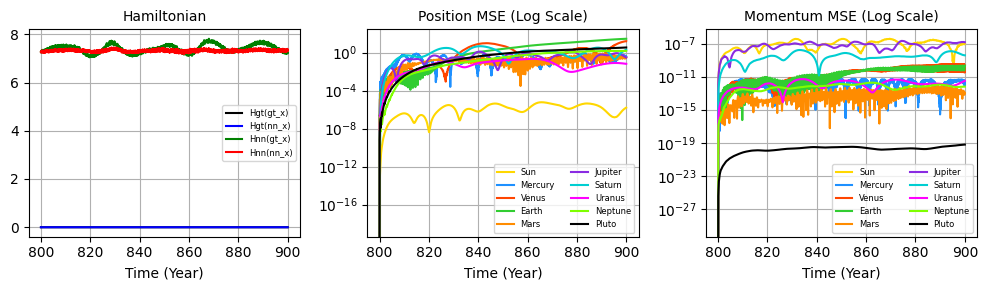

In [14]:
start_idx = 1_600_000 # 2_000_000 * 0.8
dt = 0.0005 # 1 year = 2_000 steps, so 0.0005 corresponds to 1 step = 0.0005 year, and 1000 steps = 0.5 year,

# upto 50 Years
eval_steps = [1_000, 2_000, 4_000, 6_000, 8_000, 10_000, 20_000, 30_000, 40_000, 100_000]

if extend_time_window_upto_100Y:
   eval_steps += [200_000]
if extend_time_window_upto_200Y:
   eval_steps += [300_000, 400_000]


gt_q, gt_p = ground_truth_orbits(q_path, p_path, start_idx, eval_steps[-1])

if len(eval_steps) > 0:
    FIG_PREFIX = PREFIX
       
    eval_on_test_set(model, device, 
                 q_max, p_max, dq_max, dp_max, dt,
                 eval_steps, gt_q, gt_p, start_idx, 
                 FIG_PREFIX, weight_filename, EVAL_FIG_DIR,
                 plt_scale_pars=plt_pars, 
                 qp_cat=False, 
                 img_save=IMG_SAVE)